# Churn Prediction using Survival Analysis

This notebook uses the user-level behavioral dataset  
constructed in 1.eda_user_segmentation (`users_beh.csv`).

## Objective
To analyze **when** users are likely to churn using survival analysis,
and to understand how engagement-related features influence churn risk.


# 1. Problem Definition

# Churn Prediction using Survival Analysis

We model user churn as a **time-to-event problem**.
Users still active at the observation end are treated as censored.


In [2]:
import pandas as pd
import numpy as np

# ----------------------
# Load processed dataset
# ----------------------
df = pd.read_csv("/Users/injoo/Desktop/netflix_project/users_beh.csv")

# 2. Feature Preparation

In [ ]:
# 1. Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# 2. Handle genre_entropy column (avoid duplicates after merge)
if "genre_entropy" not in df.columns:
    if "genre_entropy_y" in df.columns:
        df["genre_entropy"] = df["genre_entropy_y"]
    elif "genre_entropy_x" in df.columns:
        df["genre_entropy"] = df["genre_entropy_x"]

# 3. Define survival event
df["event"] = (~df["is_active"]).astype(int)

# 4. Subscription duration (in days)
# Use precomputed active_days if available
if "active_days" in df.columns:
    df["subscription_duration_days"] = df["active_days"].astype("Int64")
else:
    # fallback
    df["subscription_start_date"] = pd.to_datetime(df["subscription_start_date"])
    snapshot = pd.Timestamp("2025-09-12")
    df["subscription_duration_days"] = (
        snapshot - df["subscription_start_date"]
    ).dt.days.astype("Int64")

# 5. Keep only model-relevant columns
FEATURES = [
    "freq_30d",
    "avg_watch_minutes",
    "completion_rate",
    "genre_entropy"
]

FINAL_COLS = ["user_id", "event", "subscription_duration_days"] + FEATURES

df_model = df[FINAL_COLS].dropna()

print(df_model.head())
print(df_model.shape)


      user_id  event  subscription_duration_days  freq_30d  avg_watch_minutes  \
0  user_00001      0                           0       0.0                0.0   
1  user_00002      0                           0       0.0                0.0   
2  user_00003      1                           0       0.0                0.0   
3  user_00004      0                           1       1.0               21.7   
4  user_00005      0                           0       0.0                0.0   

   completion_rate  genre_entropy  
0              0.0       2.138333  
1              0.0       2.338372  
2              0.0       1.475076  
3             77.6       2.242973  
4              0.0       2.197225  
(9981, 7)


# 3. Model: Random Survival Forest

We use a Random Survival Forest (RSF) to capture non-linear relationships
and handle censored observations without strong parametric assumptions.


In [6]:
%pip install scikit-survival

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.0/818.0 kB 11.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 35.4 MB/s  0:00:00m0:00:01
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
  Created wheel for ecos: filename=ecos-2.0.14-cp310-cp310-macosx_11_0_arm64.whl size=72466 sha256=f53c9166b8dacca136ae8f37b4fbaa2033cce1ac560077493170625512d9d0ae
  Stored in directory: /Users/injoo/Library/Caches/pip/wheels/e1/cf/5e/e0839639dc3777967d18c04d65e5233e81049a89259062c081
Successfully built ecos
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [scikit-survival] [scikit-survival]
Note: you may need to restart the kernel to use updated packages.


In [7]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

X = df[FEATURES]

y = np.array(
    [(bool(e), t) for e, t in zip(df["event"], df["subscription_duration_days"])],
    dtype=[("event", bool), ("time", float)]
)

rsf = RandomSurvivalForest(
    n_estimators=400,
    max_depth=6,
    min_samples_split=8,
    random_state=42,
    n_jobs=-1
)

rsf.fit(X, y)


,n_estimators,400
,max_depth,6
,min_samples_split,8
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


# 4. Evaluation

In [8]:
risk_scores = rsf.predict(X)
c_index = concordance_index_censored(
    y["event"], y["time"], risk_scores
)[0]

print(f"C-index: {c_index:.3f}")


C-index: 0.676


# 5. Feature Importance

In [10]:
%pip install shap

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 12.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 38.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Extract feature names used by the trained model
FEATURES = list(rsf.feature_names_in_)
X = df[FEATURES].copy()

# Prediction horizon (e.g., maximum observed time)
H = time_grid.max()   # e.g., 5.0

def risk_at_H(model, X_df, H):
    # Predict survival functions for each user
    sfs = model.predict_survival_function(X_df, return_array=False)

    risks = []
    for sf in sfs:
        grid = sf.x
        # If H is outside the time grid, use the maximum available time
        h_use = min(H, grid.max())
        # Risk = 1 - survival probability at time H
        risks.append(1.0 - float(sf(h_use)))

    return np.array(risks)


def f_risk(X_array):
    X_df = pd.DataFrame(X_array, columns=FEATURES)
    return risk_at_H(rsf, X_df, H=H)

# Background dataset used by Kernel SHAP
# (small random sample for computational efficiency)
background = X.sample(100, random_state=42)

# KernelExplainer is used because RandomSurvivalForest
# is not directly supported by model-specific SHAP explainers
explainer = shap.KernelExplainer(f_risk, background)

# Compute SHAP values for a sample of users
shap_values = explainer.shap_values(
    X.sample(100, random_state=1),
    nsamples=200
)


100%|██████████| 100/100 [00:11<00:00,  8.36it/s]


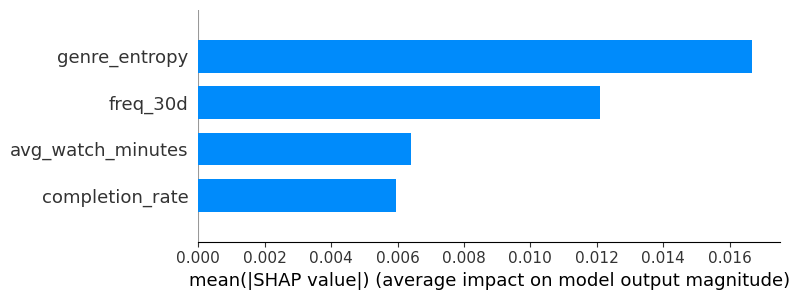

In [ ]:
# Global feature importance based on SHAP values
# Shows which features contribute most to churn risk predictions
shap.summary_plot(
    shap_values,
    X.sample(100, random_state=1),
    feature_names=FEATURES,
    plot_type="bar"
)


# 6. Key Insights

## Interpretation

- Genre diversity is the strongest predictor of churn timing,
  suggesting that users with broader viewing preferences are more resilient.
- Recent engagement frequency (last 30 days) plays a critical role in retention.
- Depth-based metrics (watch time, completion rate) are informative,
  but less influential than consistency and diversity of engagement.

## Limitations

- The dataset is synthetic and relatively sparse, which limits the strength of behavioral signals.
- Churn events are inferred from inactivity rather than explicit cancellation records.
- The analysis focuses on interpretability and behavioral insights rather than maximizing predictive performance.